Saved metrics_ESF_1d_2y_n20.csv (486 rows)


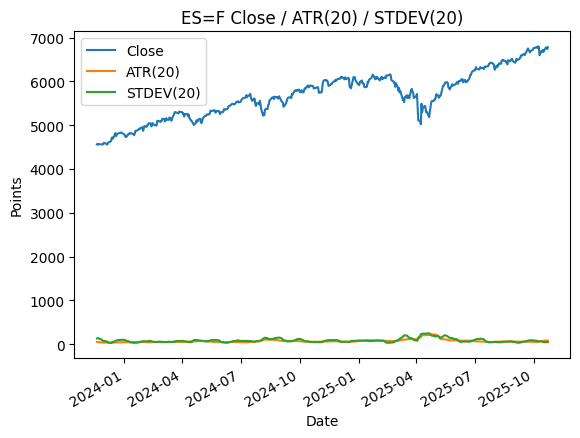

Saved metrics_NQF_1d_2y_n20.csv (486 rows)


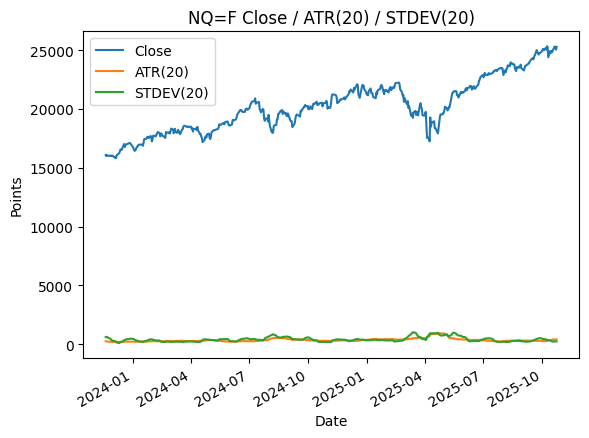

OSError: Cannot save file into a non-existent directory: 'Desktop\instrument_vol_summary'

In [22]:
"""
ATR & Standard Deviation calculator for ES and NQ (Yahoo Finance)

- Fetches historical data for ES (E-mini S&P 500) and NQ (E-mini Nasdaq 100)
  using Yahoo tickers: ES=F and NQ=F (continuous front-month series).
- Computes and saves:
    * ATR(n) — on High/Low/Close using True Range  → column: ATR(n)
    * Rolling STDEV of Close (points)               → column: STDEV(n)
    * STDEV of returns (pct & points)               → columns: stdev_ret_n_pct, stdev_ret_n_pts
- Outputs per-ticker detailed CSVs and a summary CSV with the latest snapshot:
    Ticker, Current Price, ATR(n), STDEV(n)

This script is Jupyter-safe: if run inside a notebook, it bypasses argparse and uses defaults you can edit below.

Usage (terminal examples):
    python atr_stdev_es_nq.py --lookback 20 --period 2y --interval 1d --plot
    python atr_stdev_es_nq.py --lookback 14 --period 6mo --interval 1h --tickers ES=F NQ=F
"""

import argparse
from dataclasses import dataclass
from typing import List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except ImportError:
    raise SystemExit("Please install yfinance: pip install yfinance --upgrade")


@dataclass
class Config:
    tickers: List[str]
    lookback: int
    period: str
    interval: str
    ema: bool
    plot: bool


def fetch_history(ticker: str, period: str = "2y", interval: str = "1d") -> pd.DataFrame:
    """Fetch OHLCV using yfinance.Ticker.history and ensure expected columns."""
    tk = yf.Ticker(ticker)
    df = tk.history(period=period, interval=interval, auto_adjust=False)

    if df is None or df.empty:
        raise ValueError(
            f"No data returned for {ticker} with period={period}, interval={interval}. "
            "Try a shorter period or a coarser interval (e.g., 1d or 1h)."
        )

    df = df.rename(columns={"Adj Close": "AdjClose"})
    required = {"Open", "High", "Low", "Close"}
    if not required.issubset(df.columns):
        # Attempt to extract slice if MultiIndex (rare with history)
        if isinstance(df.columns, pd.MultiIndex):
            for lvl in range(df.columns.nlevels):
                try:
                    sub = df.xs(key=ticker, axis=1, level=lvl)
                    if required.issubset(set(sub.columns)):
                        df = sub
                        break
                except Exception:
                    pass
    if not required.issubset(df.columns):
        missing = sorted(required.difference(df.columns))
        raise ValueError(f"Data for {ticker} is missing columns: {missing}")

    df = df.dropna(subset=["Open", "High", "Low", "Close"]).copy()
    df.index.name = "Date"
    return df


def true_range(df: pd.DataFrame) -> pd.Series:
    prev_close = df["Close"].shift(1)
    r1 = df["High"] - df["Low"]
    r2 = (df["High"] - prev_close).abs()
    r3 = (df["Low"] - prev_close).abs()
    return pd.concat([r1, r2, r3], axis=1).max(axis=1)


def rolling_ma(x: pd.Series, n: int, ema: bool) -> pd.Series:
    return x.ewm(span=n, adjust=False, min_periods=n).mean() if ema else x.rolling(window=n, min_periods=n).mean()


def compute_metrics(df: pd.DataFrame, n: int, ema: bool) -> pd.DataFrame:
    out = df.copy()
    tr = true_range(out)
    out[f"ATR({n})"] = rolling_ma(tr, n, ema)
    out[f"STDEV({n})"] = out["Close"].rolling(window=n, min_periods=n).std(ddof=1)
    out["ret"] = out["Close"].pct_change()
    out[f"stdev_ret_{n}_pct"] = out["ret"].rolling(window=n, min_periods=n).std(ddof=1)
    out[f"stdev_ret_{n}_pts"] = out[f"stdev_ret_{n}_pct"] * out["Close"]
    return out


def tidy_export(df: pd.DataFrame, n: int, ema: bool, ticker: str) -> pd.DataFrame:
    atr_col = f"ATR({n})"
    stdev_col = f"STDEV({n})"
    cols = [
        "Open", "High", "Low", "Close", "Volume",
        atr_col,
        stdev_col,
        f"stdev_ret_{n}_pct",
        f"stdev_ret_{n}_pts",
    ]
    available = [c for c in cols if c in df.columns]
    out = df[available].dropna().copy()
    out.reset_index(inplace=True)
    out.insert(1, "Ticker", ticker)
    return out


def run(cfg: Config):
    n = cfg.lookback
    atr_col = f"ATR({n})"
    stdev_col = f"STDEV({n})"
    summary_records = []

    for tkr in cfg.tickers:
        print(f"Downloading {tkr} ({cfg.period}, {cfg.interval}) …")
        raw = fetch_history(tkr, cfg.period, cfg.interval)
        df = compute_metrics(raw, n, cfg.ema)
        tidy = tidy_export(df, n, cfg.ema, tkr)

        latest = df.iloc[-1]
        summary_records.append({
            "Ticker": tkr,
            "Current Price": float(latest["Close"]),
            atr_col: float(latest[atr_col]),
            stdev_col: float(latest[stdev_col]),
        })

        out_csv = f"metrics_{tkr.replace('=','')}_{cfg.interval}_{cfg.period}_n{n}{'e' if cfg.ema else ''}.csv"
        tidy.to_csv(out_csv, index=False)
        print(f"Saved {out_csv} ({len(tidy):,} rows)")

        if cfg.plot:
            # Plot close with ATR and STDEV
            ax = tidy.set_index('Date')[["Close", atr_col, stdev_col]].plot(title=f"{tkr} Close / ATR({n}) / STDEV({n})")
            ax.set_xlabel("Date"); ax.set_ylabel("Points")
            plt.show()

    if summary_records:
        summary = pd.DataFrame(summary_records)
        summary.to_csv(f"Desktop\instrument_vol_summary\instrument_summary.csv", index=False)
        print("\nSaved instrument_summary.csv:")
        print(summary)


def parse_args() -> Config:
    p = argparse.ArgumentParser(description="Compute ATR(n) and STDEV(n) for ES=F and NQ=F")
    p.add_argument("--tickers", nargs="*", default=["ES=F", "NQ=F"], help="Yahoo tickers (default: ES=F NQ=F)")
    p.add_argument("--lookback", type=int, default=20, help="Rolling window length n (default: 20)")
    p.add_argument("--period", type=str, default="2y", help="Yahoo period (e.g., 6mo, 1y, 2y, 5y)")
    p.add_argument("--interval", type=str, default="1d", help="Yahoo interval (e.g., 1d, 1h, 30m, 5m)")
    p.add_argument("--ema", action="store_true", help="Use EMA for ATR smoothing (default SMA)")
    p.add_argument("--plot", action="store_true", help="Show matplotlib charts")
    a = p.parse_args()
    return Config(a.tickers, a.lookback, a.period, a.interval, a.ema, a.plot)


if __name__ == "__main__":
    import sys
    if "ipykernel" in sys.modules:
        # Jupyter/IPython safe defaults — edit here if running in a notebook
        args = argparse.Namespace(
            tickers=["ES=F", "NQ=F"],
            lookback=20,
            period="2y",
            interval="1d",
            ema=False,
            plot=True,
        )
        cfg = Config(**vars(args))
    else:
        cfg = parse_args()
    run(cfg)


Saved C:\\Users\\loci_\\Desktop\\instrument_vol_summary\metrics_ESF_1d_2y_n20.csv (486 rows)


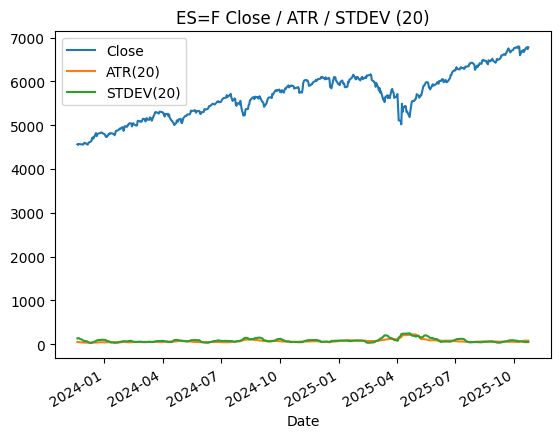

Saved C:\\Users\\loci_\\Desktop\\instrument_vol_summary\metrics_NQF_1d_2y_n20.csv (486 rows)


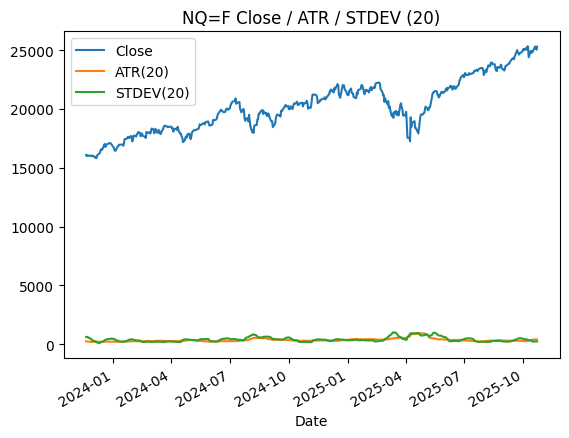

Saved C:\\Users\\loci_\\Desktop\\instrument_vol_summary\metrics_^GSPC_1d_2y_n20.csv (482 rows)


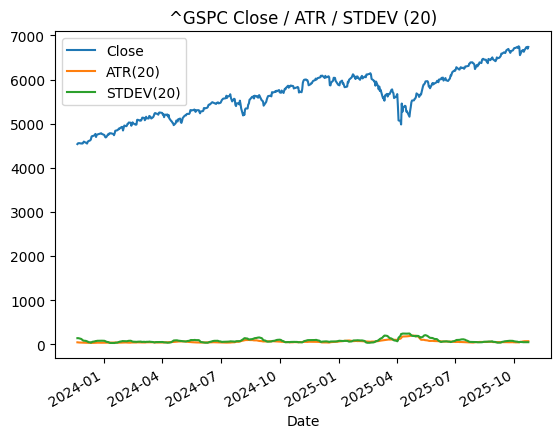

Saved C:\\Users\\loci_\\Desktop\\instrument_vol_summary\metrics_^NDX_1d_2y_n20.csv (482 rows)


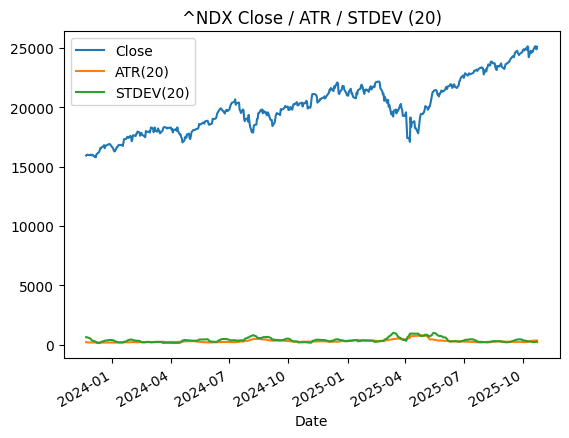

Saved C:\\Users\\loci_\\Desktop\\instrument_vol_summary\metrics_CLF_1d_2y_n20.csv (485 rows)


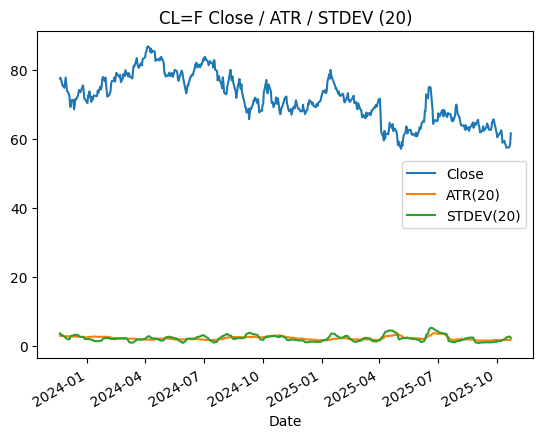

Saved C:\\Users\\loci_\\Desktop\\instrument_vol_summary\metrics_^STOXX50E_1d_2y_n20.csv (482 rows)


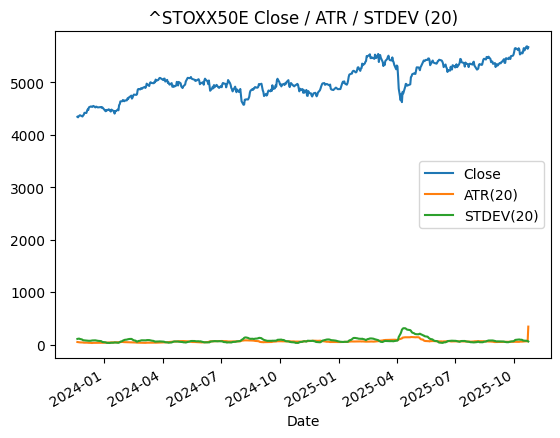

Saved C:\\Users\\loci_\\Desktop\\instrument_vol_summary\metrics_^GDAXI_1d_2y_n20.csv (490 rows)


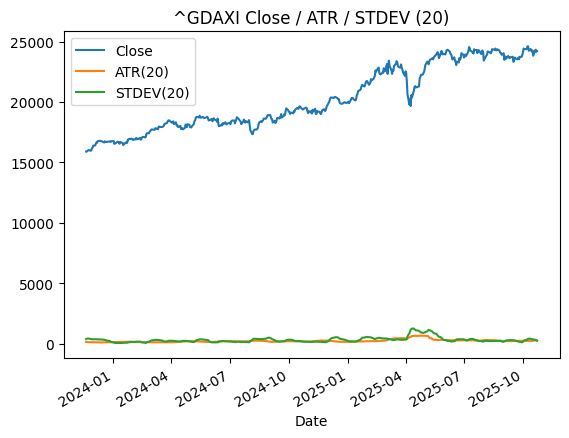

$FGBL=F: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


[WARN] Skipping FGBL=F: No data returned for FGBL=F with period=2y, interval=1d. Try shortening the period or using a coarser interval (e.g., 1d or 1h).


$FGBS=F: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


[WARN] Skipping FGBS=F: No data returned for FGBS=F with period=2y, interval=1d. Try shortening the period or using a coarser interval (e.g., 1d or 1h).

Saved C:\\Users\\loci_\\Desktop\\instrument_vol_summary\instrument_summary.csv:
  Instrument  Current Price  ATR(20)  STDEV(20)
0       ES=F        6779.75    83.09      50.66
1       NQ=F       25295.75   403.56     238.38
2      ^GSPC        6738.44    72.74      49.98
3       ^NDX       25097.42   349.20     241.00
4       CL=F          61.64     1.77       2.30
5  ^STOXX50E        5668.33   341.53      57.69
6     ^GDAXI       24207.79   272.94     251.30


: 

In [ ]:
r"""
ATR & Standard Deviation calculator for multiple instruments (Yahoo Finance)

- Uses ATR(n) and STDEV(n) columns
- Saves per-ticker CSVs and summary CSV into:
    C:\Users\loci_\Desktop\instrument_vol_summary
- Handles Yahoo data gaps gracefully
- Jupyter-safe defaults include all requested instruments
"""

import argparse
from dataclasses import dataclass
from typing import List
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except ImportError as e:
    raise SystemExit("Please install yfinance: pip install yfinance --upgrade")


@dataclass
class Config:
    tickers: List[str]
    lookback: int
    period: str
    interval: str
    ema: bool
    plot: bool
    save_path: str


def fetch_history(ticker: str, period: str = "2y", interval: str = "1d") -> pd.DataFrame:
    tk = yf.Ticker(ticker)
    df = tk.history(period=period, interval=interval, auto_adjust=False)

    if df is None or df.empty:
        raise ValueError(
            f"No data returned for {ticker} with period={period}, interval={interval}. "
            "Try shortening the period or using a coarser interval (e.g., 1d or 1h)."
        )

    df = df.rename(columns={"Adj Close": "AdjClose"})
    required = {"Open", "High", "Low", "Close"}

    if not required.issubset(df.columns) and isinstance(df.columns, pd.MultiIndex):
        for lvl in range(df.columns.nlevels):
            try:
                sub = df.xs(key=ticker, axis=1, level=lvl)
                if required.issubset(set(sub.columns)):
                    df = sub
                    break
            except Exception:
                pass

    if not required.issubset(df.columns):
        missing = sorted(required.difference(df.columns))
        raise ValueError(
            f"Data for {ticker} is missing columns: {missing}. "
            "ATR needs High/Low/Close. Try a different interval or shorter period."
        )

    df = df.dropna(subset=["Open", "High", "Low", "Close"]).copy()
    df.index.name = "Date"
    return df


def true_range(df: pd.DataFrame) -> pd.Series:
    prev_close = df["Close"].shift(1)
    range1 = df["High"] - df["Low"]
    range2 = (df["High"] - prev_close).abs()
    range3 = (df["Low"] - prev_close).abs()
    return pd.concat([range1, range2, range3], axis=1).max(axis=1)


def rolling_ma(x: pd.Series, n: int, ema: bool) -> pd.Series:
    return x.ewm(span=n, adjust=False, min_periods=n).mean() if ema else x.rolling(window=n, min_periods=n).mean()


def compute_metrics(df: pd.DataFrame, n: int, ema: bool) -> pd.DataFrame:
    out = df.copy()
    tr = true_range(out)
    out[f"ATR({n})"] = rolling_ma(tr, n, ema)
    out[f"STDEV({n})"] = out["Close"].rolling(window=n, min_periods=n).std(ddof=1)
    out["ret"] = out["Close"].pct_change()
    out[f"stdev_ret_{n}_pct"] = out["ret"].rolling(window=n, min_periods=n).std(ddof=1)
    out[f"stdev_ret_{n}_pts"] = out[f"stdev_ret_{n}_pct"] * out["Close"]
    return out


def tidy_export(df: pd.DataFrame, n: int, ema: bool, ticker: str) -> pd.DataFrame:
    cols = [
        "Open", "High", "Low", "Close", "Volume",
        f"ATR({n})",
        f"STDEV({n})",
        f"stdev_ret_{n}_pct",
        f"stdev_ret_{n}_pts",
    ]
    available = [c for c in cols if c in df.columns]
    out = df[available].dropna().copy()
    out.reset_index(inplace=True)
    out.insert(1, "Ticker", ticker)
    return out


def run(cfg: Config):
    os.makedirs(cfg.save_path, exist_ok=True)

    n = cfg.lookback
    atr_col = f"ATR({n})"
    stdev_col = f"STDEV({n})"
    summary_records = []

    for tkr in cfg.tickers:
        print(f"Downloading {tkr} ({cfg.period}, {cfg.interval}) …")
        try:
            raw = fetch_history(tkr, cfg.period, cfg.interval)
        except Exception as e:
            print(f"[WARN] Skipping {tkr}: {e}")
            continue

        df = compute_metrics(raw, n, cfg.ema)
        tidy = tidy_export(df, n, cfg.ema, tkr)
        latest = df.iloc[-1]

        summary_records.append({
        "Instrument": tkr,
        "Current Price": round(float(latest["Close"]),2),
        atr_col: round(float(latest[atr_col]),2),
        stdev_col: round(float(latest[stdev_col]),2),

        })

        out_csv = f"metrics_{tkr.replace('=','')}_{cfg.interval}_{cfg.period}_n{n}{'e' if cfg.ema else ''}.csv"
        out_csv_path = os.path.join(cfg.save_path, out_csv)
        tidy.to_csv(out_csv_path, index=False)
        print(f"Saved {out_csv_path} ({len(tidy):,} rows)")

        if cfg.plot:
            tidy.set_index('Date')[["Close", atr_col, stdev_col]].plot(title=f"{tkr} Close / ATR / STDEV ({n})")
            plt.show()

    if summary_records:
        summary_df = pd.DataFrame(summary_records)
        summary_path = os.path.join(cfg.save_path, "instrument_summary.csv")
        summary_df.to_csv(summary_path, index=False)
        print(f"\nSaved {summary_path}:")
        print(summary_df)


def parse_args() -> Config:
    p = argparse.ArgumentParser(description="Compute ATR(n) and STDEV(n) for multiple instruments")
    p.add_argument("--tickers", nargs="*", default=[], help="Yahoo tickers")
    p.add_argument("--lookback", type=int, default=20, help="Rolling window length n (default: 20)")
    p.add_argument("--period", type=str, default="2y", help="Yahoo period (e.g., 6mo, 1y, 2y, 5y)")
    p.add_argument("--interval", type=str, default="1d", help="Yahoo interval (e.g., 1d, 1h, 30m, 5m)")
    p.add_argument("--ema", action="store_true", help="Use EMA for ATR smoothing (default SMA)")
    p.add_argument("--plot", action="store_true", help="Show matplotlib charts")
    p.add_argument("--save_path", type=str, default=r"C:\\Users\\loci_\\Desktop\\instrument_vol_summary")
    a = p.parse_args()

    default_universe = ["ES=F", "NQ=F", "^GSPC", "^NDX", "CL=F", "^STOXX50E", "^GDAXI", "FGBL=F", "FGBS=F"]
    tickers = a.tickers if a.tickers else default_universe
    return Config(tickers, a.lookback, a.period, a.interval, a.ema, a.plot, a.save_path)


if __name__ == "__main__":
    import sys
    if "ipykernel" in sys.modules:
        args = argparse.Namespace(
            tickers=["ES=F", "NQ=F", "^GSPC", "^NDX", "CL=F", "^STOXX50E", "^GDAXI", "FGBL=F", "FGBS=F"],
            lookback=20,
            period="2y",
            interval="1d",
            ema=False,
            plot=True,
            save_path=r"C:\\Users\\loci_\\Desktop\\instrument_vol_summary",
        )
        cfg = Config(**vars(args))
    else:
        cfg = parse_args()
    run(cfg)
